First we do a principal component analysis to reduce the dimension of the bundles data


PCA puis residualisation

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from neurostatx.io.loader import DatasetLoader
from neurostatx.utils.preprocessing import merge_dataframes
from neurostatx.statistics.models import permutation_testing
from neurostatx. io.viz import generate_coef_plot

from scipy import stats
from statsmodels.regression.linear_model import OLS
from itertools import product

from sklearn.impute import KNNImputer  
from sklearn.metrics import mean_absolute_error, mean_squared_error, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import CCA
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


In [2]:
# Setting up relevant paths
repository_path = "c:/Users/Rosalie/OneDrive - Office 365/Documents/UdeS/Hiver 2026/Crédits de recherche/GitHub/FuzzyClustering-PING"
data_dir = "c:/Users/Rosalie/OneDrive - Office 365/Documents/UdeS/Hiver 2026/Crédits de recherche/data/"
ping_cfa_dir = "c:/Users/Rosalie/OneDrive - Office 365/Documents/UdeS/Hiver 2026/Crédits de recherche/result/preprocessing/PING_CFA_Apply/"
data_filtered_dir = "c:/Users/Rosalie/OneDrive - Office 365/Documents/UdeS/Hiver 2026/Crédits de recherche/result/PCA/"
output_dir = "c:/Users/Rosalie/OneDrive - Office 365/Documents/UdeS/Hiver 2026/Crédits de recherche/result/PCA/"

# Create output directory if it doesn't exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [3]:
# Load ping data
ping_cfa = pd.read_excel(f"{ping_cfa_dir}/transformed_dataset.xlsx")

# Load bundles
bundles = pd.read_csv(f"{data_dir}/bundles_mean_stats.tsv", sep='\t')

In [4]:
# Enlever sub- dans la colonne sample du dataset bundles pour faciliter la fusion avec le dataset ping_cfa
bundles['sample'] = bundles['sample'].str.replace('sub-', '', regex=False)

# Convertir en string des deux côtés pour éviter les faux mismatch
ping_cfa["Sample"] = ping_cfa["Sample"].astype(str)
bundles["sample"] = bundles["sample"].astype(str) 

# Filter le dataset ping_cfa pour ne garder que les individus présents dans le dataset bundles
ping_cfa_filtered = ping_cfa[ping_cfa['Sample'].isin(bundles['sample'])].copy()

# Filter le sataset bundles pour ne garder que les individus présents dans le dataset ping_cfa
bundles_filtered = bundles[bundles['sample'].isin(ping_cfa['Sample'])].copy()

ping_cfa_filtered.to_excel(f"{output_dir}/ping_data_filtered_for_bundles.xlsx", index=False, header=True)
bundles_filtered.to_excel(f"{output_dir}/bundles_data_filtered_for_ping.xlsx", index=False, header=True)

In [5]:
# Load ping data
ping_ori = pd.read_excel(f"{data_filtered_dir}/ping_data_filtered_for_bundles.xlsx")

# Load bundles
bundles_ori = pd.read_excel(f"{data_filtered_dir}/bundles_data_filtered_for_ping.xlsx")

In [6]:
# convertir en numérique
measure_cols = bundles_ori.columns[3:]
bundles_ori[measure_cols] = bundles_ori[measure_cols].apply(pd.to_numeric, errors="coerce")
bundles_scaled_tot = bundles_ori.copy()

# Standardiser les donnees des bundles avec mean=0 et std=1 pour les colonnes de mesures
bundles_scaled_tot[measure_cols] = pd.DataFrame(StandardScaler().fit_transform(bundles_ori[measure_cols]))

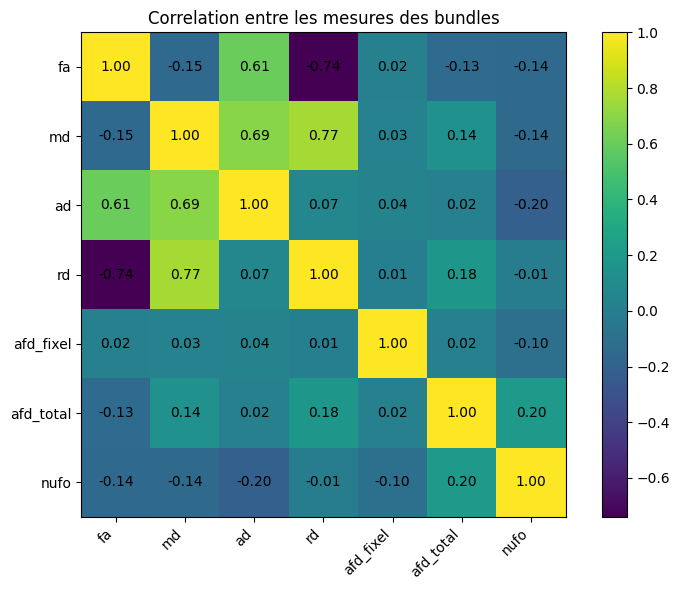

In [15]:
# Matrice de corrélation pour les mesures des bundles
measure_cols = bundles_scaled_tot[["fa", "md", "ad", "rd", "afd_fixel", "afd_total", "nufo"]].columns
corr_matrix = bundles_scaled_tot[measure_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix, interpolation="nearest")
plt.colorbar(im)

ax.set_xticks(range(len(measure_cols)))
ax.set_yticks(range(len(measure_cols)))
ax.set_xticklabels(measure_cols, rotation=45, ha="right")
ax.set_yticklabels(measure_cols)

for i in range(len(measure_cols)):
    for j in range(len(measure_cols)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                ha="center", va="center")

ax.set_title("Correlation entre les mesures des bundles")
plt.tight_layout()
plt.show()

In [7]:
# Performing PCA 
selected_cols = ["md", "rd", "ad", "nufo", "afd_fixel", "afd_total"]
bundles_scaled = bundles_scaled_tot[["sample", "bundle"] + selected_cols]

pca = PCA()
principal_components = pca.fit_transform(bundles_scaled[selected_cols])
principal_df = pd.DataFrame(data=principal_components, columns=[f"PC{i+1}" for i in range(principal_components.shape[1])])

# Garder les composantes avec eigenvalues >= 1
n_keep = np.sum(pca.explained_variance_ >= 1)
if n_keep == 0:
    n_keep = 1

principal_df = pd.DataFrame(
    data=principal_components[:, :n_keep],
    columns=[f"PC{i+1}" for i in range(n_keep)],
      index=bundles_scaled.index)

# Ajouter les colonnes "sample" et "bundle" au DataFrame des scores PCA
principal_df.insert(0, "sample", bundles_scaled["sample"].values)
principal_df.insert(1, "bundle", bundles_scaled.iloc[:, 1].values)

# variance expliquée
pca_summary = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(pca.explained_variance_))],
    "Eigenvalue": pca.explained_variance_,
    "Explained_variance_ratio": pca.explained_variance_ratio_,
    "Cumulative_variance": pca.explained_variance_ratio_.cumsum()
})
# loadings
pca_loadings = pd.DataFrame(
    pca.components_.T,
    index=selected_cols,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

In [17]:
print(pca_summary)

    PC    Eigenvalue  Explained_variance_ratio  Cumulative_variance
0  PC1  2.128718e+00              3.547691e-01             0.354769
1  PC2  1.302375e+00              2.170520e-01             0.571821
2  PC3  1.001879e+00              1.669718e-01             0.738793
3  PC4  8.486506e-01              1.414349e-01             0.880228
4  PC5  7.186685e-01              1.197723e-01             1.000000
5  PC6  1.430396e-11              2.383878e-12             1.000000


In [18]:
print(pca_loadings)

                PC1       PC2       PC3       PC4       PC5           PC6
md         0.679156  0.020891 -0.067675 -0.034635  0.129199  7.182192e-01
rd         0.514109  0.307678  0.018958 -0.607948 -0.011791 -5.205067e-01
ad         0.476828 -0.314318 -0.126627  0.631405  0.214240 -4.617727e-01
nufo      -0.151531  0.646898 -0.033958  0.184157  0.723529  3.156757e-08
afd_fixel  0.051933 -0.203562  0.945601 -0.034388  0.246011  5.478153e-09
afd_total  0.146342  0.588377  0.289330  0.442076 -0.594352  4.492164e-08


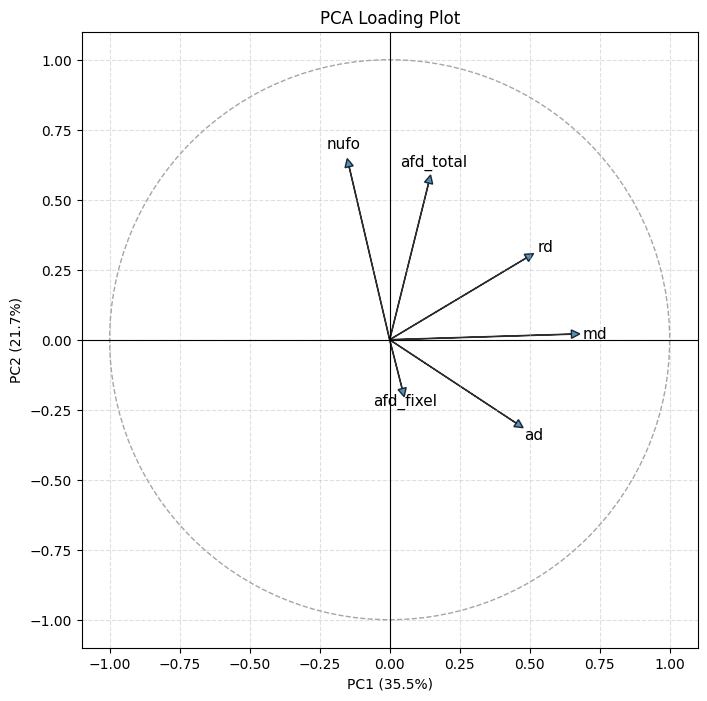

In [8]:
# Extraire les loadings de PC1 et PC2
pc1 = pca_loadings["PC1"]
pc2 = pca_loadings["PC2"]

# Figure
plt.figure(figsize=(8, 8))

# Cercle de corrélation simple
circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--', alpha=0.7)
plt.gca().add_artist(circle)

# Tracer les vecteurs
for var in selected_cols:
    x = pc1[var]
    y = pc2[var]
    
    plt.arrow(
        0, 0, x, y,
        head_width=0.03,
        head_length=0.03,
        length_includes_head=True,
        alpha=0.8
    )
    plt.text(
        x * 1.08,
        y * 1.08,
        var,
        fontsize=11,
        ha='center',
        va='center'
    )

# Axes
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)

# Labels avec variance expliquée
var_pc1 = pca.explained_variance_ratio_[0] * 100
var_pc2 = pca.explained_variance_ratio_[1] * 100

plt.xlabel(f"PC1 ({var_pc1:.1f}%)")
plt.ylabel(f"PC2 ({var_pc2:.1f}%)")
plt.title("PCA Loading Plot")
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True, linestyle='--', alpha=0.4)

plt.show()

In [9]:
# Pivoter et reformuler les lignes et colonnes pour les pc
sample_col = principal_df.columns[0]
bundle_col = principal_df.columns[1]
pc_cols = principal_df.columns[2:]

# pivot : une ligne par sample, colonnes = bundle x pc
bundles_pivot = principal_df.pivot(index=sample_col, columns=bundle_col, values=pc_cols)

In [11]:
# Filtrer les colonnes avec 20% ou plus de valeurs manquantes
missing_pct = bundles_pivot.isna().mean() * 100
cols_to_keep = missing_pct[missing_pct < 20].index
bundles_20 = bundles_pivot.loc[:, cols_to_keep].copy()

vars = ["AF_L", "AF_R", "CC_Fr_1", "CC_Fr_2", "CC_Oc", "CC_Pa", "CC_Pr_Po", "CC_Te",
        "CG_L", "CG_R", "FAT_L", "FAT_R", "FPT_L", "FPT_R", "FX_L", "FX_R", "ICP_L", "ICP_R",
        "IFOF_L", "IFOF_R", "ILF_L", "ILF_R", "MCP", "MdLF_L", "MdLF_R", "OR_ML_L", "OR_ML_R",
        "POPT_L", "POPT_R", "PYT_L", "PYT_R", "SCP_L", "SCP_R", "SLF_L", "SLF_R", "UF_L", "UF_R"]

bundles_20 = bundles_20.loc[:, bundles_20.columns.get_level_values(1).isin(vars)]

# colonnes supprimées
cols_removed = [
    col for col in bundles_pivot.columns
    if (missing_pct[col] >= 20) and (col[1] in vars)
]

print("Nombre de colonnes supprimées :", len(cols_removed))
print("Colonnes supprimées :")
print(list(cols_removed))

Nombre de colonnes supprimées : 0
Colonnes supprimées :
[]


In [22]:
# Préparer les mêmes masques pour tous les k
rng = np.random.default_rng(42)

# prendre seulement un sous-ensemble de colonnes pour choisir k
n_test_cols = min(20, bundles_20.shape[1])
test_cols = rng.choice(bundles_20.columns, size=n_test_cols, replace=False)

X_test = bundles_20[test_cols].copy()

# créer un seul plan de masquage
mask_fraction = 0.20
masked_positions = []

X_masked = X_test.copy()

for col in test_cols:
    observed_idx = X_test.index[X_test[col].notna()]
    if len(observed_idx) < 10:
        continue

    n_mask = max(2, int(len(observed_idx) * mask_fraction))
    chosen_idx = rng.choice(observed_idx, size=n_mask, replace=False)

    for idx in chosen_idx:
        masked_positions.append((idx, col))

    X_masked.loc[chosen_idx, col] = np.nan

In [23]:
# tester quelques k 
k_values = [5, 7, 10, 15, 20, 25, 30, 40, 50, 60, 70]
results = []

for k in k_values:
    imputer = KNNImputer(
        n_neighbors=k,
        weights="distance",
        metric="nan_euclidean"
    )

    X_imputed = pd.DataFrame(
        imputer.fit_transform(X_masked),
        index=X_masked.index,
        columns=X_masked.columns
    )

    true_vals = np.array([X_test.loc[idx, col] for idx, col in masked_positions], dtype=float)
    pred_vals = np.array([X_imputed.loc[idx, col] for idx, col in masked_positions], dtype=float)

    rmse = np.sqrt(mean_squared_error(true_vals, pred_vals))
    results.append({"k": k, "rmse": rmse})

results_df = pd.DataFrame(results).sort_values("rmse").reset_index(drop=True)


In [24]:
# Afficher les résultats et choisir le meilleur k
print(results_df[["k", "rmse"]])
best_k = results_df.loc[0, "k"]
print("Best k:", best_k)

     k      rmse
0   15  1.981257
1   10  1.981508
2   20  1.983434
3   25  1.984872
4   30  1.985085
5   40  1.987825
6   50  1.989859
7    7  1.991669
8   60  1.991783
9   70  1.993728
10   5  1.995793
Best k: 15


In [25]:
# Impute the missing values in bundles using the best KNN imputer
imputer = KNNImputer(
    n_neighbors=best_k,
    weights="distance",
    metric="nan_euclidean"
)

bundles_imputed = pd.DataFrame(
    imputer.fit_transform(bundles_20),
    columns=bundles_20.columns,
    index=bundles_20.index
)

In [26]:
# Gerer la colonne/index sample pour le merge
ping_for_merge = ping_ori.copy()
ping_for_merge = ping_for_merge.rename(columns={"Sample": "sample"})
ping_for_merge["sample"] = ping_for_merge["sample"].astype(str)

bundles_for_merge = bundles_imputed.reset_index()
bundles_for_merge["sample"] = bundles_for_merge["sample"].astype(str)

# Verifier l'ordre des samples
(ping_for_merge["sample"].values == bundles_for_merge["sample"].values).all()

np.True_

In [27]:
# Merge
ping_and_bundles = merge_dataframes({"ping" : ping_for_merge, "bundles" : bundles_for_merge}, index="sample")

In [28]:
# Residualisation des bundles pour age, sex, handedness, etchnicity
# Separate the covariates and the variates data
covars = ping_and_bundles[["Sex", "AgeMonths", "Ethnicity", "Handedness"]].copy()
vars = ping_and_bundles.iloc[:, 15:].copy()

covars = sm.add_constant(covars)

# Instantiating an empty dataframe to store the results
residuals = pd.DataFrame(index=ping_and_bundles.index)

# Running a linear regression model for eact variate
for var in vars.columns:
    model = OLS(vars[var], covars)
    results = model.fit()
    residuals[var] = results.resid

C:\Users\Rosalie\AppData\Local\Temp\ipykernel_23360\1364079151.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  residuals[var] = results.resid
C:\Users\Rosalie\AppData\Local\Temp\ipykernel_23360\1364079151.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  residuals[var] = results.resid
C:\Users\Rosalie\AppData\Local\Temp\ipykernel_23360\1364079151.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all co

In [29]:
# Merging the residuals with the original data
ping_bundles_resid = pd.concat([ping_and_bundles.drop(columns=vars), residuals], axis=1)

# Saving the residualized data.
ping_bundles_resid.to_excel(f"{output_dir}/ping_bundles_residualized.xlsx", index=True, header=True)

In [30]:
# Verifier que la residiualisation a bien fonctionné
X = sm.add_constant(ping_and_bundles[["AgeMonths", "Sex", "Ethnicity", "Handedness"]])

for col in residuals.columns:
    model = sm.OLS(residuals[col], X).fit()
    print(f"\n{col}")
    print(model.summary().tables[1])
# Coef environ 0 = pas de relation entre les covariables et les variables d'intérêt, ce qui est le but de la residualisation.
# P values élevés (1) = pas de relation significative entre les covariables et les variables d'intérêt, ce qui est également le but de la residualisation.


('PC1', 'AF_L')
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.722e-16      0.259  -6.64e-16      1.000      -0.510       0.510
AgeMonths   9.723e-16      0.001    1.1e-12      1.000      -0.002       0.002
Sex         9.515e-16      0.077   1.24e-14      1.000      -0.150       0.150
Ethnicity  -1.804e-16      0.023  -7.85e-15      1.000      -0.045       0.045
Handedness  3.221e-16      0.102   3.17e-15      1.000      -0.200       0.200

('PC1', 'AF_R')
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -3.361e-16      0.262  -1.28e-15      1.000      -0.515       0.515
AgeMonths   1.013e-15      0.001   1.13e-12      1.000      -0.002       0.002
Sex         9.185e-16      0.077   1.19e-14      1.000      -0.152       0.152
Ethnicity  -1.681e

CCA

AVEC PC 1

In [66]:
# Perform Canonical Correlation Analysis avec 3 composantes (car 3 variables cognitives)

cols_after_14 = ping_bundles_resid.columns[14:]
pc1_cols = [col for col in cols_after_14 if isinstance(col, tuple) and col[0] == "PC1"]
X1 = ping_bundles_resid.loc[:, pc1_cols]
X1.index = ping_bundles_resid.index

Y1 = ping_bundles_resid[["VA", "EFPS", "MEM"]] # Y = variables cognitives
Y1.index = ping_bundles_resid.index

cca = CCA(n_components=3)
X1_c, Y1_c = cca.fit_transform(X1, Y1)

# Calculate and print the canonical correlations for each pair of canonical variables
canonical_corrs = []
for i in range(3):
    corr = np.corrcoef(X1_c[:, i], Y1_c[:, i])[0, 1]
    canonical_corrs.append(corr)
    print(f"Dimension canonique {i+1} : r = {corr:.3f}")

bundle_labels = [col[1] if isinstance(col, tuple) else str(col) for col in X1.columns]

coef_df = pd.DataFrame(
    cca.coef_,
    index=Y1.columns,      # lignes = variables cognitives
    columns=bundle_labels     # colonnes = bundles PC1
)
coef_df

Dimension canonique 1 : r = 0.420
Dimension canonique 2 : r = 0.320
Dimension canonique 3 : r = 0.288


,AF_L,AF_R,CC_Fr_1,CC_Fr_2,CC_Oc,CC_Pa,CC_Pr_Po,CC_Te,CG_L,CG_L_An,...,PYT_L,PYT_L_Brainstem,PYT_R,PYT_R_Brainstem,SCP_L,SCP_R,SLF_L,SLF_R,UF_L,UF_R
VA,0.009932,-0.032406,0.040545,-0.027596,0.007661,-0.027974,0.000553,-0.010116,0.036021,-0.066301,...,-0.192871,0.075448,0.111353,-0.053855,0.007549,0.008793,-0.058667,0.043150,0.037053,0.005417
EFPS,0.022236,0.051427,0.013864,0.007660,0.006701,0.007513,-0.004958,-0.002768,0.061288,-0.079286,...,-0.009562,-0.001309,0.045897,-0.032480,-0.011039,0.027149,-0.035213,-0.068641,-0.024976,0.034566
MEM,0.073927,-0.046212,0.037267,-0.001686,-0.023206,-0.016246,0.003534,-0.006788,0.022193,-0.026457,...,-0.188450,0.051911,0.153127,-0.014249,0.005375,0.004324,-0.103531,-0.014429,-0.005356,0.017609


In [70]:
# Calculer les loadings des faisceaux pour la première dimension canonique 
bundles_scores_PC1 = X1_c[:, 0]

bundles_loadings_PC1 = pd.Series(
    [np.corrcoef(X1.iloc[:, j], bundles_scores_PC1)[0, 1] for j in range(X1.shape[1])],
    index=X1.columns,
    name="loading_CCA1"
).sort_values(key=lambda s: abs(s), ascending=False)

bundles_loadings_PC1

(PC1, UF_L)               -0.339539
(PC1, UF_R)               -0.335181
(PC1, CC_Fr_1)            -0.316906
(PC1, CC_Pr_Po)            0.249703
(PC1, CG_L_Po)            -0.248430
(PC1, FAT_R)              -0.205299
(PC1, CC_Pa)               0.196670
(PC1, CC_Te)               0.191857
(PC1, IFOF_R)             -0.158920
(PC1, SLF_R)              -0.144802
(PC1, PYT_R_Brainstem)     0.133800
(PC1, ICP_L)               0.133026
(PC1, AF_R)               -0.131676
(PC1, FAT_L)              -0.120974
(PC1, POPT_L_Brainstem)    0.119856
(PC1, IFOF_L)             -0.113736
(PC1, CG_R_Po)            -0.109863
(PC1, PYT_L)               0.104247
(PC1, POPT_L)              0.098279
(PC1, FPT_R_Brainstem)     0.088872
(PC1, CC_Oc)               0.086426
(PC1, MCP)                -0.080382
(PC1, POPT_R_Brainstem)    0.077760
(PC1, CG_R_An)            -0.077084
(PC1, POPT_R)              0.073774
(PC1, PYT_L_Brainstem)     0.073716
(PC1, SCP_L)              -0.073438
(PC1, MdLF_R)             -0

In [71]:
#  Calculer les loadings des variables cognitives pour la première dimension canonique
cog_scores_PC1 = Y1_c[:, 0]

cog_loadings_PC1 = pd.Series(
    [np.corrcoef(Y1.iloc[:, j], cog_scores_PC1)[0, 1] for j in range(Y1.shape[1])],
    index=Y1.columns,
    name="loading_CCA1"
)

cog_loadings_PC1

VA     -0.925685
EFPS   -0.124699
MEM    -0.588607
Name: loading_CCA1, dtype: float64

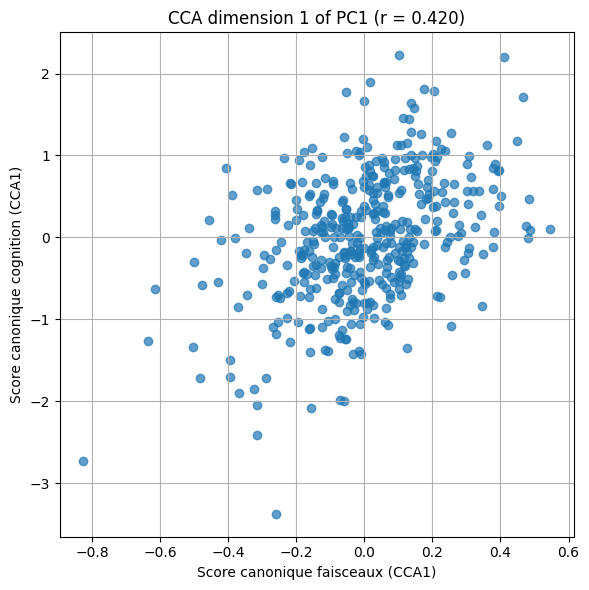

In [54]:
# Visualiser les scores canoniques pour la première dimension
plt.figure(figsize=(6, 6))
plt.scatter(X1_c[:, 0], Y1_c[:, 0], alpha=0.7)
plt.xlabel("Score canonique faisceaux (CCA1)")
plt.ylabel("Score canonique cognition (CCA1)")
plt.title(f"CCA dimension 1 of PC1 (r = {canonical_corrs[0]:.3f})")
plt.grid(True)
plt.tight_layout()
plt.show()

AVEC PC 2

In [73]:
# Perform Canonical Correlation Analysis avec 3 composantes (car 3 variables cognitives)

pc2_cols = [col for col in cols_after_14 if isinstance(col, tuple) and col[0] == "PC2"]
X2 = ping_bundles_resid.loc[:, pc2_cols]
X2.index = ping_bundles_resid.index

Y2 = ping_bundles_resid[["VA", "EFPS", "MEM"]] # Y = variables cognitives
Y2.index = ping_bundles_resid.index

cca = CCA(n_components=3)
X2_c, Y2_c = cca.fit_transform(X2, Y2)

# Calculate and print the canonical correlations for each pair of canonical variables
canonical_corrs = []
for i in range(3):
    corr = np.corrcoef(X2_c[:, i], Y2_c[:, i])[0, 1]
    canonical_corrs.append(corr)
    print(f"Dimension canonique {i+1} : r = {corr:.3f}")

bundle_labels_PC2 = [col[1] if isinstance(col, tuple) else str(col) for col in X2.columns]

coef_df_PC2 = pd.DataFrame(
    cca.coef_,
    index=Y2.columns,      # lignes = variables cognitives
    columns=bundle_labels_PC2     # colonnes = bundles PC2
)
coef_df_PC2

Dimension canonique 1 : r = 0.410
Dimension canonique 2 : r = 0.370
Dimension canonique 3 : r = 0.329


,AF_L,AF_R,CC_Fr_1,CC_Fr_2,CC_Oc,CC_Pa,CC_Pr_Po,CC_Te,CG_L,CG_L_An,...,PYT_L,PYT_L_Brainstem,PYT_R,PYT_R_Brainstem,SCP_L,SCP_R,SLF_L,SLF_R,UF_L,UF_R
VA,-0.007101,0.056517,-0.003309,-0.049104,0.033009,-0.005190,0.049561,-0.028465,0.008126,-0.006336,...,-0.151966,0.030891,-0.013668,0.048782,-0.001198,0.020580,0.002224,-0.029717,0.038249,-0.039907
EFPS,-0.029863,0.000517,0.012612,0.001839,-0.033085,-0.017724,0.048681,0.032256,-0.029423,0.006673,...,-0.108007,0.077423,0.005862,0.007667,0.004496,-0.009240,0.007775,0.020819,-0.029341,0.006844
MEM,-0.009271,0.056851,0.027141,0.007617,-0.001226,-0.035321,-0.011978,0.024651,0.044659,-0.034779,...,0.167662,-0.062595,-0.200404,-0.047157,0.011945,-0.009395,0.023024,-0.027016,-0.027946,0.020363


Top 20 bundles les plus influents :
FPT_L               0.224136
FPT_L_Brainstem     0.216805
PYT_R               0.200404
POPT_R_Brainstem    0.172293
PYT_L               0.167662
POPT_R              0.157509
FPT_R_Brainstem     0.142827
FPT_R               0.132345
ILF_R               0.123127
POPT_L              0.122189
CG_R                0.114980
CG_R_An             0.108563
POPT_L_Brainstem    0.094313
IFOF_L              0.083137
PYT_L_Brainstem     0.077423
FAT_L               0.069492
IFOF_R              0.059562
AF_R                0.056851
FAT_R               0.054364
CC_Pr_Po            0.049561
dtype: float64


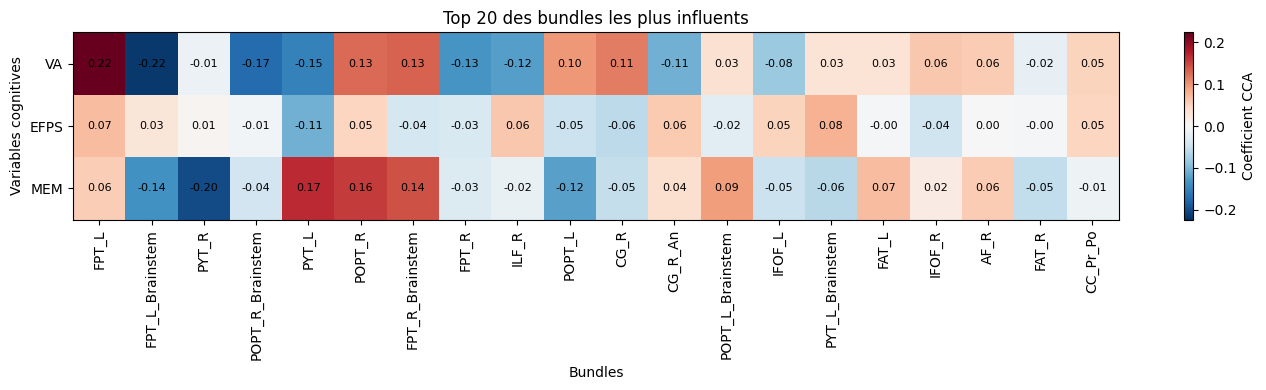

In [74]:
# Importance globale de chaque bundle
bundle_import_PC2 = coef_df_PC2.abs().max(axis=0)

# Top 20 bundles les plus influents
top20_bundles_PC2 = bundle_import_PC2.sort_values(ascending=False).head(20).index

# Sous-tableau pour la heatmap
coef_top20_PC2 = coef_df_PC2.loc[:, top20_bundles_PC2]

# Optionnel : réordonner les colonnes du plus influent au moins influent
coef_top20_PC2 = coef_top20_PC2.loc[:, bundle_import_PC2[top20_bundles_PC2].sort_values(ascending=False).index]

print("Top 20 bundles les plus influents :")
print(bundle_import_PC2.loc[coef_top20_PC2.columns].sort_values(ascending=False))

# Heatmap
fig, ax = plt.subplots(figsize=(14, 4))

vmax = np.abs(coef_top20_PC2.values).max()
im = ax.imshow(coef_top20_PC2.values, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Coefficient CCA")

ax.set_xticks(np.arange(coef_top20_PC2.shape[1]))
ax.set_xticklabels(coef_top20_PC2.columns, rotation=90)
ax.set_yticks(np.arange(coef_top20_PC2.shape[0]))
ax.set_yticklabels(coef_top20_PC2.index)

ax.set_title("Top 20 des bundles les plus influents")
ax.set_xlabel("Bundles")
ax.set_ylabel("Variables cognitives")

# Écrire les valeurs dans chaque case
for i in range(coef_top20_PC2.shape[0]):
    for j in range(coef_top20_PC2.shape[1]):
        value = coef_top20_PC2.iloc[i, j]
        ax.text(
            j, i, f"{value:.2f}",
            ha="center", va="center",
            fontsize=8,
            color="black"
        )

plt.tight_layout()
plt.show()

In [56]:
# Calculer les loadings des faisceaux pour la première dimension canonique 
bundles_scores_PC2 = X2_c[:, 0]

bundles_loadings_PC2 = pd.Series(
    [np.corrcoef(X2.iloc[:, j], bundles_scores_PC2)[0, 1] for j in range(X2.shape[1])],
    index=X2.columns,
    name="loading_CCA1"
).sort_values(key=lambda s: abs(s), ascending=False)

bundles_loadings_PC2

(PC2, CG_L_Po)            -0.268565
(PC2, UF_L)               -0.220944
(PC2, UF_R)               -0.216375
(PC2, IFOF_L)             -0.157173
(PC2, MdLF_L)             -0.127361
(PC2, POPT_L)             -0.126245
(PC2, ILF_L)              -0.121465
(PC2, POPT_L_Brainstem)   -0.118014
(PC2, IFOF_R)             -0.107162
(PC2, AF_R)                0.105939
(PC2, PYT_L_Brainstem)    -0.097197
(PC2, PYT_R)              -0.096611
(PC2, PYT_L)              -0.096551
(PC2, SLF_R)               0.095795
(PC2, PYT_R_Brainstem)    -0.095037
(PC2, FX_L)                0.088140
(PC2, SLF_L)               0.087710
(PC2, CG_L_An)            -0.085122
(PC2, FPT_R)              -0.081473
(PC2, POPT_R_Brainstem)   -0.076868
(PC2, CG_R)               -0.076068
(PC2, CG_L)               -0.072099
(PC2, ILF_R)              -0.070610
(PC2, FPT_L_Brainstem)    -0.065384
(PC2, CC_Oc)              -0.064494
(PC2, POPT_R)             -0.059618
(PC2, FPT_R_Brainstem)    -0.057625
(PC2, CG_R_An)            -0

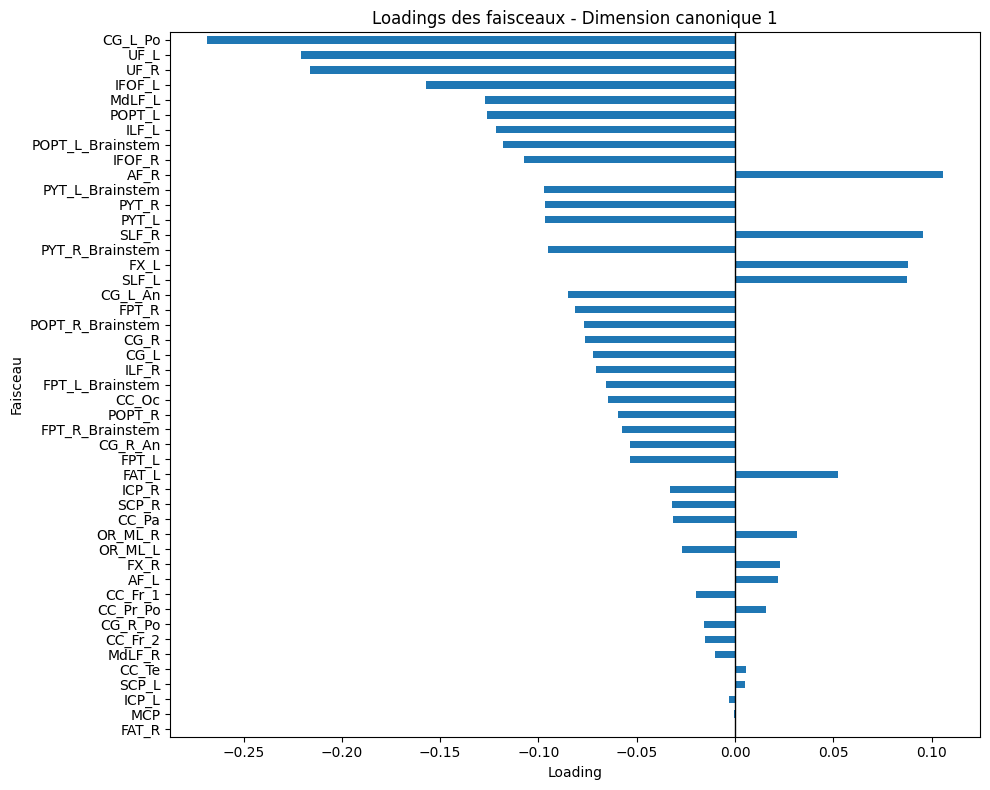

In [57]:
loadings_plot_PC2 = bundles_loadings_PC2.copy()
loadings_plot_PC2.index = [idx[1] if isinstance(idx, tuple) else idx for idx in loadings_plot_PC2.index]

plt.figure(figsize=(10, 8))
loadings_plot_PC2.iloc[::-1].plot(kind="barh")

plt.xlabel("Loading")
plt.ylabel("Faisceau")
plt.title("Loadings des faisceaux - Dimension canonique 1")
plt.axvline(0, color="black", linewidth=1)

plt.tight_layout()
plt.show()

In [58]:
#  Calculer les loadings des variables cognitives pour la première dimension canonique
cog_scores_PC2 = Y2_c[:, 0]

cog_loadings_PC2 = pd.Series(
    [np.corrcoef(Y2.iloc[:, j], cog_scores_PC2)[0, 1] for j in range(Y2.shape[1])],
    index=Y2.columns,
    name="loading_CCA1"
)

cog_loadings_PC2

VA      0.834770
EFPS    0.839387
MEM     0.893384
Name: loading_CCA1, dtype: float64

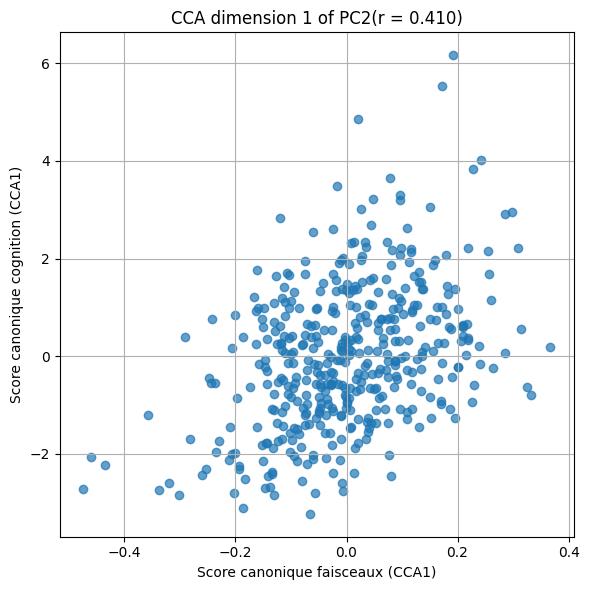

In [59]:
# Visualiser les scores canoniques pour la première dimension
plt.figure(figsize=(6, 6))
plt.scatter(X2_c[:, 0], Y2_c[:, 0], alpha=0.7)
plt.xlabel("Score canonique faisceaux (CCA1)")
plt.ylabel("Score canonique cognition (CCA1)")
plt.title(f"CCA dimension 1 of PC2(r = {canonical_corrs[0]:.3f})")
plt.grid(True)
plt.tight_layout()
plt.show()


AVEC PC 3

In [ ]:
# Perform Canonical Correlation Analysis avec 3 composantes (car 3 variables cognitives)

pc3_cols = [col for col in cols_after_14 if isinstance(col, tuple) and col[0] == "PC3"]
X3 = ping_bundles_resid.loc[:, pc3_cols]
X3.index = ping_bundles_resid.index

Y3 = ping_bundles_resid[["VA", "EFPS", "MEM"]] # Y = variables cognitives
Y3.index = ping_bundles_resid.index

cca = CCA(n_components=3)
X3_c, Y3_c = cca.fit_transform(X3, Y3)

# Calculate and print the canonical correlations for each pair of canonical variables
canonical_corrs = []
for i in range(3):
    corr = np.corrcoef(X3_c[:, i], Y3_c[:, i])[0, 1]
    canonical_corrs.append(corr)
    print(f"Dimension canonique {i+1} : r = {corr:.3f}")


Dimension canonique 1 : r = 0.401
Dimension canonique 2 : r = 0.371
Dimension canonique 3 : r = 0.292


,AF_L,AF_R,CC_Fr_1,CC_Fr_2,CC_Oc,CC_Pa,CC_Pr_Po,CC_Te,CG_L,CG_L_An,...,PYT_L,PYT_L_Brainstem,PYT_R,PYT_R_Brainstem,SCP_L,SCP_R,SLF_L,SLF_R,UF_L,UF_R
VA,-0.034267,0.092841,-0.048397,0.009439,0.027528,-0.045512,0.080958,0.001116,-0.058206,0.069532,...,0.103978,-0.050285,-0.156667,0.028729,-0.010510,0.009277,0.044912,-0.050097,0.068375,-0.029230
EFPS,-0.042721,0.010821,-0.022743,-0.053708,0.012475,-0.040071,0.064766,0.003224,-0.052259,0.046869,...,-0.043978,0.077068,-0.150556,0.010816,0.026016,-0.018246,0.061614,0.010369,0.063450,-0.012751
MEM,-0.186520,0.144382,0.085293,-0.126342,-0.003171,0.060214,0.006844,0.003045,-0.040635,0.078150,...,0.172031,-0.051944,-0.153440,-0.142391,-0.006876,-0.077258,0.040823,-0.027268,-0.075334,0.012896


In [ ]:
#À SUPPRIMER
# Importance globale de chaque bundle
bundle_import_PC3 = coef_df_PC3.abs().max(axis=0)

# Top 20 bundles les plus influents
top20_bundles_PC3 = bundle_import_PC3.sort_values(ascending=False).head(20).index

# Sous-tableau pour la heatmap
coef_top20_PC3 = coef_df_PC3.loc[:, top20_bundles_PC3]

# Optionnel : réordonner les colonnes du plus influent au moins influent
coef_top20_PC3 = coef_top20_PC3.loc[:, bundle_import_PC3[top20_bundles_PC3].sort_values(ascending=False).index]

print("Top 20 bundles les plus influents :")
print(bundle_import_PC3.loc[coef_top20_PC3.columns].sort_values(ascending=False))

# Heatmap
fig, ax = plt.subplots(figsize=(14, 4))

vmax = np.abs(coef_top20_PC3.values).max()
im = ax.imshow(coef_top20_PC3.values, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Coefficient CCA")

ax.set_xticks(np.arange(coef_top20_PC3.shape[1]))
ax.set_xticklabels(coef_top20_PC3.columns, rotation=90)
ax.set_yticks(np.arange(coef_top20_PC3.shape[0]))
ax.set_yticklabels(coef_top20_PC3.index)

ax.set_title("Top 20 des bundles les plus influents")
ax.set_xlabel("Bundles")
ax.set_ylabel("Variables cognitives")

# Écrire les valeurs dans chaque case
for i in range(coef_top20_PC3.shape[0]):
    for j in range(coef_top20_PC3.shape[1]):
        value = coef_top20_PC3.iloc[i, j]
        ax.text(
            j, i, f"{value:.2f}",
            ha="center", va="center",
            fontsize=8,
            color="black"
        )

plt.tight_layout()
plt.show()

In [61]:
# Calculer les loadings des faisceaux pour la première dimension canonique 
bundles_scores_PC3 = X3_c[:, 0]

bundles_loadings_PC3 = pd.Series(
    [np.corrcoef(X3.iloc[:, j], bundles_scores_PC3)[0, 1] for j in range(X3.shape[1])],
    index=X3.columns,
    name="loading_CCA1"
).sort_values(key=lambda s: abs(s), ascending=False)

bundles_loadings_PC3

(PC3, UF_R)               -0.547504
(PC3, CG_L_Po)            -0.541846
(PC3, UF_L)               -0.470751
(PC3, IFOF_L)             -0.468952
(PC3, IFOF_R)             -0.466812
(PC3, CC_Fr_1)            -0.463174
(PC3, FAT_R)              -0.452624
(PC3, ILF_R)              -0.445648
(PC3, FAT_L)              -0.397365
(PC3, ILF_L)              -0.395513
(PC3, MdLF_R)             -0.380735
(PC3, AF_L)               -0.374887
(PC3, SLF_R)              -0.370656
(PC3, AF_R)               -0.361225
(PC3, CG_R_Po)            -0.341132
(PC3, MdLF_L)             -0.326027
(PC3, OR_ML_L)            -0.290993
(PC3, CG_L)               -0.275109
(PC3, SLF_L)              -0.262823
(PC3, CC_Fr_2)            -0.256057
(PC3, CG_R_An)            -0.253705
(PC3, CG_R)               -0.239969
(PC3, OR_ML_R)            -0.230847
(PC3, CG_L_An)            -0.214659
(PC3, SCP_R)              -0.197835
(PC3, CC_Oc)              -0.184945
(PC3, CC_Te)              -0.173998
(PC3, ICP_L)              -0

In [62]:
#  Calculer les loadings des variables cognitives pour la première dimension canonique
cog_scores_PC3 = Y3_c[:, 0]

cog_loadings_PC3 = pd.Series(
    [np.corrcoef(Y3.iloc[:, j], cog_scores_PC3)[0, 1] for j in range(Y3.shape[1])],
    index=Y3.columns,
    name="loading_CCA1"
).sort_values(key=lambda s: abs(s), ascending=False)

cog_loadings_PC3

VA      0.972083
MEM     0.720471
EFPS    0.267535
Name: loading_CCA1, dtype: float64

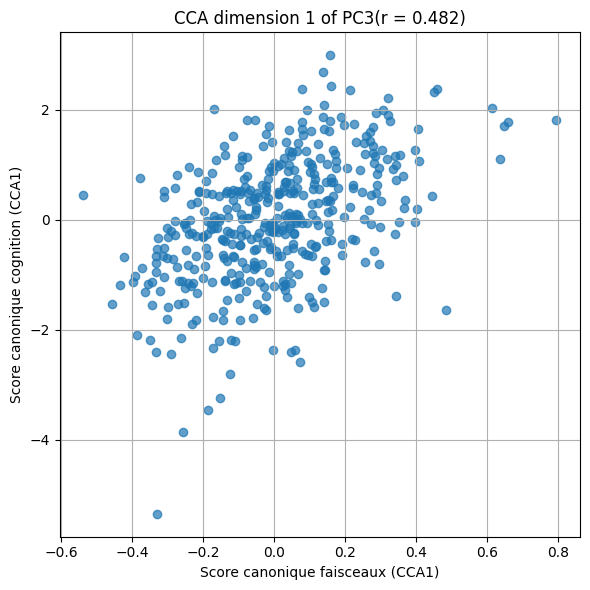

In [34]:
# Visualiser les scores canoniques pour la première dimension
plt.figure(figsize=(6, 6))
plt.scatter(X3_c[:, 0], Y3_c[:, 0], alpha=0.7)
plt.xlabel("Score canonique faisceaux (CCA1)")
plt.ylabel("Score canonique cognition (CCA1)")
plt.title(f"CCA dimension 1 of PC3(r = {canonical_corrs[0]:.3f})")
plt.grid(True)
plt.tight_layout()
plt.show()

In [121]:
# Performing permutation testing
mod3, score3, coef3, perm_score3, score_pval3, perm_coef3, coef_pval3 = permutation_testing(
    cca,
    X3,
    Y3,
    nb_permutations=1000,
    processes=4,
    verbose= True,
    scoring="r2",
    splits=10
)

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:   17.4s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:   29.3s
[Parallel(n_jobs=4)]: Done 442 tasks      | elapsed:   51.3s
[Parallel(n_jobs=4)]: Done 792 tasks      | elapsed:  1.5min
[Parallel(n_jobs=4)]: Done 1000 out of 1000 | elapsed:  1.9min finished


In [ ]:
# Exporter les coefficients et les p-values dans des fichiers Excel
bundles_name3 = bundle_labels
coef_val3 = {f'coef{i+1}': coef3[:, i] for i in range (0, 3)}
coef_val3["varname"] = bundles_name3
coef_df3 = pd.DataFrame(coef_val3)
coef_df3.to_excel(f"{output_dir}/cca3_coef.xlsx", index=False, header=True)

coef_pval_df3 = pd.DataFrame(coef_pval3, index=bundles_name3, columns=["VA", "EFPS", "MEM"])
coef_pval_df3.to_excel(f"{output_dir}/cca3_coef_pval.xlsx", index=True, header=True)

In [123]:
# Générer les plots pour chaque composante canonique
for i in range(Y3.shape[1]):
    generate_coef_plot(
        coef_df3,
        coef_pval3[:, i],
        coefname = f"coef{i+1}",
        varname = "varname",
        output=f"{output_dir}/cca3_coef_{i+1}.png"
    )

In [124]:
coef_df3.set_index("varname", inplace=True)
coef_df3.columns = ["VA", "EFPS", "MEM"]

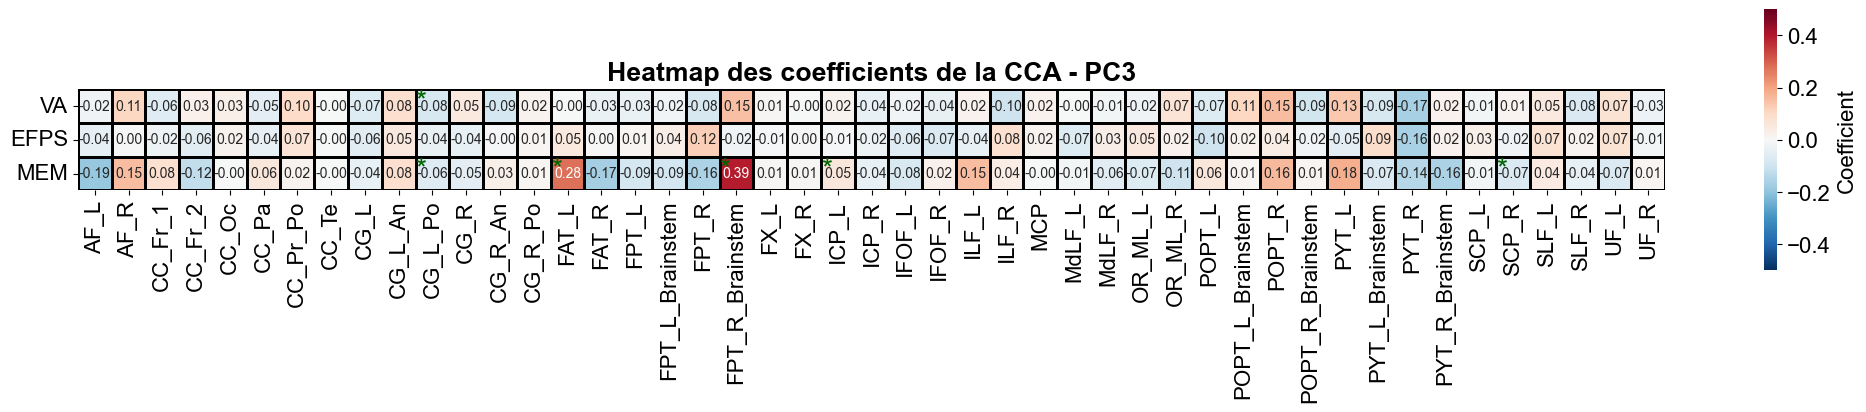

In [125]:
# Heatmap des coefficients de la CCA (PC3)

plotting_parameters3 = {
    "data" : coef_df3.T,
    "cmap" : "RdBu_r",
    "vmin" : -0.5,
    "vmax" : 0.5,
    "center" : 0,
    "annot" : True,
    "annot_kws" : {"fontsize": 10},
    "fmt" : ".2f",
    "robust" : True,
    "linewidths" : 0.8,
    "linecolor" : "black",
    "cbar_kws" : {"label": "Coefficient", "shrink": 0.4},
    "square" : True,
}

with plt.rc_context(
        {"font.family" : "Arial",
        "font.size" : 16, "font.weight" : "normal", "axes.titleweight" : "bold",
        }
    ) :
        fig, ax = plt.subplots(figsize=(21, 7))
        heatmap = sns.heatmap(ax=ax, **plotting_parameters3)

        ax.set_xlabel("")
        ax.set_title("Heatmap des coefficients de la CCA - PC3")

        for i, j in product(range(coef_pval_df3.T.shape[0]), range(coef_pval_df3.T.shape[1])):
            if coef_pval_df3.T.iloc[i, j] < 0.05:
                ax.text(j, i, "*", ha="left", va="top", color="darkgreen", fontsize=20)
        
        plt.tight_layout()
        plt.savefig(f"{output_dir}/cca3_coef_heatmap.png", dpi=900)
        plt.show()